# Bordür Analizi ve Hough Çizgi Tespiti (Day 12)
Hough çizgi tespiti (PPHT) ile Merinos halı bordürlerinin (TOP, BOTTOM, LEFT, RIGHT) belirlenmesi, açısal paralellik sapmalarının ve rulo kalite kontrol kararlarının incelenmesi.

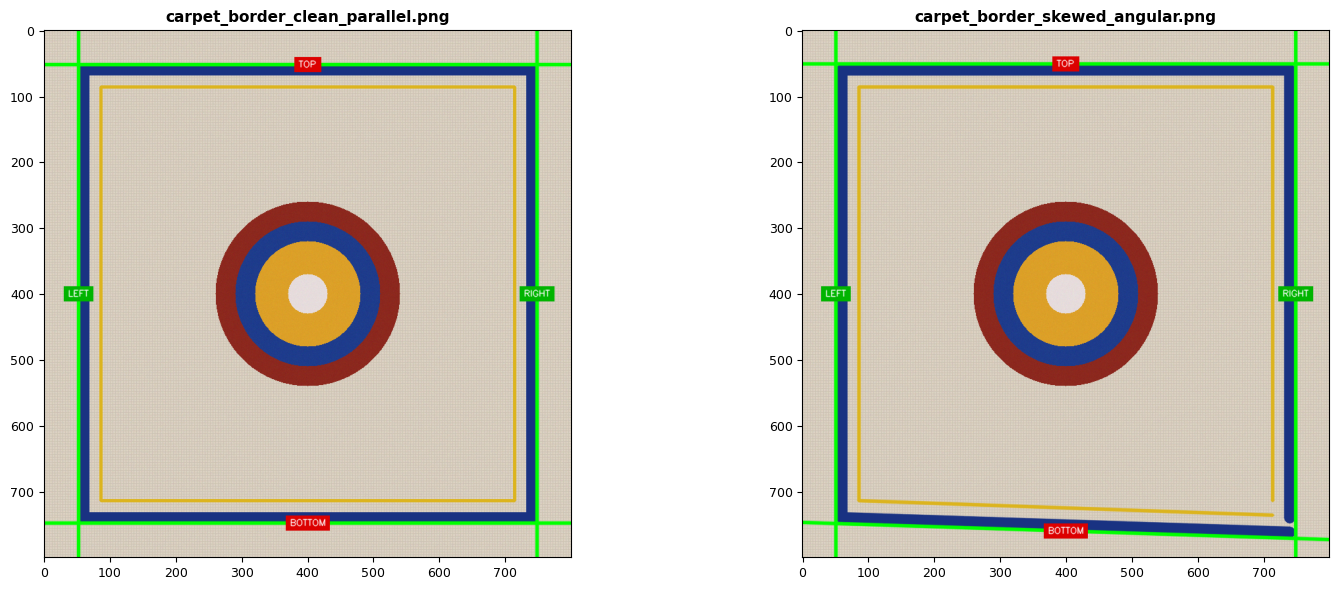

In [1]:
import sys
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent.parent if CURRENT_DIR.name == "notebooks" else (CURRENT_DIR.parent if CURRENT_DIR.name == "day12" else CURRENT_DIR)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from day12.mini_project.src.border_analyzer import CarpetBorderAnalyzer
from day12.mini_project.src.generator import CarpetBorderFixtureGenerator

analyzer = CarpetBorderAnalyzer()
generator = CarpetBorderFixtureGenerator(seed=42)

fixtures_dir = PROJECT_ROOT / "day12" / "mini_project" / "fixtures" / "synthetic_carpets"
clean_path = fixtures_dir / "carpet_border_clean_parallel.png"
skewed_path = fixtures_dir / "carpet_border_skewed_angular.png"

if clean_path.exists():
    clean_carpet = cv2.imdecode(np.fromfile(str(clean_path), dtype=np.uint8), cv2.IMREAD_COLOR)
else:
    clean_carpet = generator.generate_clean_parallel_carpet(width=800, height=600)

if skewed_path.exists():
    skewed_carpet = cv2.imdecode(np.fromfile(str(skewed_path), dtype=np.uint8), cv2.IMREAD_COLOR)
else:
    skewed_carpet = generator.generate_skewed_angular_carpet(width=800, height=600, skew_angle_deg=1.85)

clean_report, clean_inter = analyzer.analyze_carpet(clean_carpet, edge_method="CANNY")
skewed_report, skewed_inter = analyzer.analyze_carpet(skewed_carpet, edge_method="CANNY")

def draw_border_badges(image, borders):
    overlay = image.copy()
    for side, border in borders.items():
        if border:
            p1 = (int(round(border.x1)), int(round(border.y1)))
            p2 = (int(round(border.x2)), int(round(border.y2)))
            cv2.line(overlay, p1, p2, (0, 255, 0), 3, cv2.LINE_AA)
            
            mid_x = int(round((border.x1 + border.x2) / 2.0))
            mid_y = int(round((border.y1 + border.y2) / 2.0))
            
            badge_color = (0, 0, 220) if side in ["TOP", "BOTTOM"] else (0, 180, 0)
            text = side
            (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
            
            pad = 6
            x1 = mid_x - tw // 2 - pad
            y1 = mid_y - th // 2 - pad
            x2 = mid_x + tw // 2 + pad
            y2 = mid_y + th // 2 + pad
            
            cv2.rectangle(overlay, (x1, y1), (x2, y2), badge_color, -1)
            cv2.putText(overlay, text, (mid_x - tw // 2, mid_y + th // 2 - 1),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)
    return overlay

clean_vis = draw_border_badges(clean_carpet, clean_report.borders)
skewed_vis = draw_border_badges(skewed_carpet, skewed_report.borders)

# Şekil 24: Yan yana 2'li panel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(cv2.cvtColor(clean_vis, cv2.COLOR_BGR2RGB))
axes[0].set_title("carpet_border_clean_parallel.png", fontsize=11, fontweight="bold")
axes[0].tick_params(axis='both', labelsize=9)

axes[1].imshow(cv2.cvtColor(skewed_vis, cv2.COLOR_BGR2RGB))
axes[1].set_title("carpet_border_skewed_angular.png", fontsize=11, fontweight="bold")
axes[1].tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.show()

## 2. Paralellik ve Kalite Değerlendirme Raporu

In [2]:
import pandas as pd
from IPython.display import display

data = [
    {
        "Fikstür": "carpet_border_clean_parallel.png",
        "Yatay Açı Farkı": f"{clean_report.horizontal_parallelism.angle_difference_deg:.3f}°",
        "Dikey Açı Farkı": f"{clean_report.vertical_parallelism.angle_difference_deg:.3f}°",
        "Diklik Sapması": f"{clean_report.orthogonality_deviation_deg:.3f}°" if clean_report.orthogonality_deviation_deg else "N/A",
        "Kalite Kararı": clean_report.decision.value,
        "İşlem Süresi": f"{clean_report.processing_time_ms:.1f} ms"
    },
    {
        "Fikstür": "carpet_border_skewed_angular.png",
        "Yatay Açı Farkı": f"{skewed_report.horizontal_parallelism.angle_difference_deg:.3f}°",
        "Dikey Açı Farkı": f"{skewed_report.vertical_parallelism.angle_difference_deg:.3f}°",
        "Diklik Sapması": f"{skewed_report.orthogonality_deviation_deg:.3f}°" if skewed_report.orthogonality_deviation_deg else "N/A",
        "Kalite Kararı": skewed_report.decision.value,
        "İşlem Süresi": f"{skewed_report.processing_time_ms:.1f} ms"
    }
]

df = pd.DataFrame(data)
display(df)

,Fikstür,Yatay Açı Farkı,Dikey Açı Farkı,Diklik Sapması,Kalite Kararı,İşlem Süresi
0,carpet_border_clean_parallel.png,0.000°,0.000°,N/A,ACCEPT,10.2 ms
1,carpet_border_skewed_angular.png,1.881°,0.000°,0.941°,REJECT,5.9 ms
